# Demo 1: PulseAI 4-Case Simulated Run (5 Minutes)

This notebook runs a deterministic 5-minute simulation (4 x 75-second cases) and saves evidence artifacts for presentation.

## Objective and Cases

1. Case 1: Person doing heavy workout in gym\n
2. Case 2: Person sleeping after gym\n
3. Case 3: Elderly person getting attack\n
4. Case 4: Elderly person climbing hill

In [ ]:
# Optional Colab setup: mount Drive and switch to PULSEAI project root.
import os
from pathlib import Path

try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive', force_remount=False)
except Exception as exc:
    print('Drive mount skipped or unavailable:', exc)

project_candidates = [
    Path('/content/drive/MyDrive/PULSEAI'),
    Path('/content/drive/MyDrive/PULSEAI-main'),
    Path('/content/PULSEAI'),
]

project_root = None
for candidate in project_candidates:
    if (candidate / 'backend').exists() and (candidate / 'docs').exists():
        project_root = candidate
        break

if project_root is not None:
    os.chdir(project_root)
    print('Using project root:', project_root)
else:
    print('Project root not found yet. Keep running, fallback mode will be used if backend is unavailable.')
    print('Expected one of:', [str(p) for p in project_candidates])

print('cwd now:', os.getcwd())

Mounted at /content/drive
Using project root: /content/drive/MyDrive/PULSEAI
cwd now: /content/drive/MyDrive/PULSEAI


In [ ]:
# Optional: locate trained .h5 and set MODEL_PATH before importing backend ml_model.
from pathlib import Path
import os
import sys

model_candidates = [
    Path('hctg_net_model.h5').resolve(),
    Path('backend/hctg_net_model.h5').resolve(),
    Path('/content/hctg_net_model.h5'),
    Path('/content/drive/MyDrive/PulseAI_Models/hctg_net_model.h5'),
    Path('/content/drive/MyDrive/PULSEAI/hctg_net_model.h5'),
    Path('/content/drive/MyDrive/PULSEAI/backend/hctg_net_model.h5'),
    Path('/content/drive/MyDrive/PULSEAI-main/hctg_net_model.h5'),
]

selected_model = None
for m in model_candidates:
    if m.exists():
        selected_model = m
        break

if selected_model is not None:
    os.environ['MODEL_PATH'] = str(selected_model)
    print('Using MODEL_PATH:', selected_model)
else:
    print('No trained .h5 found in candidate locations. Backend will use heuristic mode.')

# Force reimport so ml_model re-reads MODEL_PATH on next import.
for mod in ['ml_model', 'signal_processing']:
    if mod in sys.modules:
        del sys.modules[mod]
print('Cleared module cache for:', ['ml_model', 'signal_processing'])

Using MODEL_PATH: /content/drive/MyDrive/PulseAI_Models/hctg_net_model.h5
Cleared module cache for: ['ml_model', 'signal_processing']


In [12]:
import os
from pathlib import Path

print('cwd:', os.getcwd())
print('cwd entries (first 20):', sorted([p.name for p in Path(os.getcwd()).iterdir()])[:20])
print('has backend in cwd?', Path(os.getcwd(), 'backend').exists())

cwd: /content
cwd entries (first 20): ['.config', 'docs', 'sample_data']
has backend in cwd? False


In [25]:
import os
import sys
import json
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_backend_dir() -> Path | None:
    cwd = Path(os.getcwd()).resolve()
    candidates = [
        cwd / 'backend',
        cwd.parent / 'backend',
        Path('backend').resolve(),
        Path('/content/PULSEAI/backend'),
        Path('/content/drive/MyDrive/PULSEAI/backend'),
        Path('/content/drive/MyDrive/PULSEAI-main/backend'),
        Path(r'g:/My Drive/PULSEAI/backend'),
    ]

    for candidate in candidates:
        if candidate.exists() and (candidate / 'signal_processing.py').exists() and (candidate / 'ml_model.py').exists():
            return candidate

    for base in [cwd, *cwd.parents]:
        probe = base / 'backend'
        if probe.exists() and (probe / 'signal_processing.py').exists() and (probe / 'ml_model.py').exists():
            return probe

    return None


BACKEND_DIR = _find_backend_dir()
USING_BACKEND_IMPORT = BACKEND_DIR is not None

if USING_BACKEND_IMPORT:
    if str(BACKEND_DIR) not in sys.path:
        sys.path.insert(0, str(BACKEND_DIR))
    from signal_processing import process_ecg, extract_beat_window
    from ml_model import predict_arrhythmia, get_model_status
else:
    from scipy import signal as sp_signal
    from scipy.signal import find_peaks

    SEGMENT_LEN = 250

    def _bandpass_coeffs(lowcut=0.5, highcut=40.0, fs=500, order=4):
        nyq = 0.5 * fs
        return sp_signal.butter(order, [lowcut / nyq, highcut / nyq], btype='band')

    def _notch_coeffs(freq=50.0, fs=500, q=30):
        return sp_signal.iirnotch(freq / (fs / 2.0), q)

    def process_ecg(raw_signal_buffer: list, fs: int = 500) -> list:
        if len(raw_signal_buffer) < 10:
            return raw_signal_buffer
        data = np.array(raw_signal_buffer, dtype=np.float64)
        b_hp, a_hp = sp_signal.butter(4, 0.5 / (fs / 2.0), btype='high')
        data = sp_signal.filtfilt(b_hp, a_hp, data)
        b_n, a_n = _notch_coeffs(50.0, fs)
        data = sp_signal.filtfilt(b_n, a_n, data)
        b_bp, a_bp = _bandpass_coeffs(0.5, 40.0, fs)
        data = sp_signal.filtfilt(b_bp, a_bp, data)
        return data.tolist()

    def extract_beat_window(cleaned_signal: list, r_peak_idx: int = None) -> list:
        data = np.array(cleaned_signal, dtype=np.float32)
        if r_peak_idx is None:
            r_peak_idx = len(data) // 2
        half = SEGMENT_LEN // 2
        start = max(0, r_peak_idx - half)
        end = start + SEGMENT_LEN
        if end > len(data):
            end = len(data)
            start = max(0, end - SEGMENT_LEN)
        window = data[start:end]
        if len(window) < SEGMENT_LEN:
            window = np.pad(window, (0, SEGMENT_LEN - len(window)), mode='edge')
        std = window.std()
        if std > 1e-6:
            window = (window - window.mean()) / std
        return window.tolist()

    def _heuristic_predict(cleaned_ecg_window: list) -> dict:
        signal_window = np.array(cleaned_ecg_window, dtype=np.float32)
        if signal_window.size < 40:
            return {
                'is_arrhythmia': False,
                'classification': 'Insufficient Signal',
                'confidence': 0.55,
                'heart_rate_bpm': None,
                'rr_cv': None,
                'signal_quality': 'poor',
                'model_used': 'demo-fallback-heuristic',
                'explainability_map': None,
            }

        std = float(np.std(signal_window))
        z = (signal_window - float(np.mean(signal_window))) / std if std > 1e-6 else np.zeros_like(signal_window)

        peak_height = max(0.8, float(np.percentile(z, 92)))
        min_distance = int(0.25 * 500)
        peaks, _ = find_peaks(z, distance=min_distance, height=peak_height)

        if len(peaks) < 2:
            return {
                'is_arrhythmia': False,
                'classification': 'Normal Sinus Rhythm',
                'confidence': 0.62,
                'heart_rate_bpm': None,
                'rr_cv': None,
                'signal_quality': 'fair',
                'model_used': 'demo-fallback-heuristic',
                'explainability_map': None,
            }

        rr = np.diff(peaks) / 500.0
        rr_mean = float(np.mean(rr))
        rr_cv = float(np.std(rr) / max(rr_mean, 1e-6))
        heart_rate = float(60.0 / max(rr_mean, 1e-6))

        if rr_cv >= 0.13 and len(rr) >= 3:
            classification = 'Atrial Fibrillation (AFib)'
        elif heart_rate > 110.0:
            classification = 'Tachycardia Pattern'
        elif heart_rate < 45.0:
            classification = 'Bradycardia Pattern'
        else:
            classification = 'Normal Sinus Rhythm'

        is_arrhythmia = classification != 'Normal Sinus Rhythm'
        confidence = float(np.clip(0.60 + (0.35 if is_arrhythmia else 0.18), 0.50, 0.97))

        return {
            'is_arrhythmia': is_arrhythmia,
            'classification': classification,
            'confidence': round(confidence, 3),
            'heart_rate_bpm': round(heart_rate, 1),
            'rr_cv': round(rr_cv, 3),
            'signal_quality': 'good',
            'model_used': 'demo-fallback-heuristic',
            'explainability_map': None,
        }

    predict_arrhythmia = _heuristic_predict

    def get_model_status() -> dict:
        return {
            'model_loaded': False,
            'model_used': 'demo-fallback-heuristic',
            'model_path': 'backend-not-found-in-runtime',
        }

np.random.seed(42)
FS = 500
PHASE_SECONDS = 75
TOTAL_CASES = 4
TOTAL_SECONDS = PHASE_SECONDS * TOTAL_CASES
OUT_DIR = os.path.join('docs', 'demo1')
os.makedirs(OUT_DIR, exist_ok=True)

MODEL_STATUS = get_model_status()

CASE_MAP = {
    1: {'name': 'Heavy Workout', 'target_hr': 145, 'arrhythmia': False, 'expected': 'Tachycardia Pattern'},
    2: {'name': 'Sleeping After Gym', 'target_hr': 62, 'arrhythmia': False, 'expected': 'Normal Sinus Rhythm'},
    3: {'name': 'Elderly Attack', 'target_hr': 155, 'arrhythmia': True, 'expected': 'Atrial Fibrillation (AFib)'},
    4: {'name': 'Elderly Climbing Hill', 'target_hr': 115, 'arrhythmia': False, 'expected': 'Normal Sinus Rhythm'}
}

print('Backend import mode:', USING_BACKEND_IMPORT)
print('Backend path:', BACKEND_DIR)
print('Model status:', MODEL_STATUS)

Backend import mode: True
Backend path: /content/drive/MyDrive/PULSEAI/backend
Model status: {'model_loaded': True, 'model_used': 'keras:hctg_net_model.h5', 'model_path': '/content/drive/MyDrive/PulseAI_Models/hctg_net_model.h5'}


In [7]:
def simulate_ecg_for_case(case_id: int, seconds: int = PHASE_SECONDS, fs: int = FS):
    cfg = CASE_MAP[case_id]
    n = seconds * fs
    t = np.arange(n) / fs

    hr = cfg['target_hr']
    rr = 60.0 / hr

    signal = np.zeros_like(t, dtype=float)
    beat_times = []

    cur = 0.0
    while cur < seconds:
        jitter = np.random.uniform(-0.22, 0.22) if cfg['arrhythmia'] else np.random.uniform(-0.02, 0.02)
        interval = max(0.25, rr * (1 + jitter))
        beat_times.append(cur)
        cur += interval

    for bt in beat_times:
        qrs = 1.3 * np.exp(-((t - bt) ** 2) / (2 * 0.0045 ** 2))
        p_wave = 0.15 * np.exp(-((t - (bt - 0.12)) ** 2) / (2 * 0.02 ** 2))
        t_wave = 0.35 * np.exp(-((t - (bt + 0.2)) ** 2) / (2 * 0.04 ** 2))
        signal += (qrs + p_wave + t_wave)

    noise = np.random.normal(0, 0.03, size=n)
    if cfg['arrhythmia']:
        noise += np.random.normal(0, 0.09, size=n)

    baseline = 0.03 * np.sin(2 * np.pi * 0.33 * t)
    signal = (signal + noise + baseline) * 100

    if len(beat_times) > 1:
        rr_intervals = np.diff(beat_times)
        bpm = float(60.0 / np.mean(rr_intervals))
        rr_cv = float(np.std(rr_intervals) / np.mean(rr_intervals))
    else:
        bpm = float(hr)
        rr_cv = 0.0

    return signal, bpm, rr_cv


def to_risk_level(prediction: dict) -> str:
    if prediction.get('classification') == 'Atrial Fibrillation (AFib)':
        return 'critical'
    if prediction.get('is_arrhythmia'):
        return 'high'
    hr = prediction.get('heart_rate_bpm')
    if isinstance(hr, (int, float)) and hr >= 110:
        return 'moderate'
    return 'low'

In [26]:
rows = []
all_signals = {}
start_ts = datetime.now(timezone.utc)

for case_id in [1, 2, 3, 4]:
    s, bpm, rr_cv = simulate_ecg_for_case(case_id)

    cleaned = process_ecg(s.tolist(), fs=FS)
    model_window = extract_beat_window(cleaned)
    pred = predict_arrhythmia(model_window)
    risk = to_risk_level(pred)

    rows.append({
        'case_id': case_id,
        'case_name': CASE_MAP[case_id]['name'],
        'duration_seconds': PHASE_SECONDS,
        'expected_pattern': CASE_MAP[case_id]['expected'],
        'simulated_bpm': round(bpm, 2),
        'simulated_rr_cv': round(rr_cv, 4),
        'model_classification': pred.get('classification'),
        'risk_level': risk,
        'confidence': pred.get('confidence'),
        'model_hr_bpm': pred.get('heart_rate_bpm'),
        'model_rr_cv': pred.get('rr_cv'),
        'signal_quality': pred.get('signal_quality'),
        'model_used': pred.get('model_used')
    })

    all_signals[case_id] = s

end_ts = datetime.now(timezone.utc)
summary_df = pd.DataFrame(rows)
summary_df

,case_id,case_name,duration_seconds,expected_pattern,simulated_bpm,simulated_rr_cv,model_classification,risk_level,confidence,model_hr_bpm,model_rr_cv,signal_quality,model_used
0,1,Heavy Workout,75,Tachycardia Pattern,145.17,0.0117,Atrial Fibrillation (AFib),critical,0.883,None,None,good,keras:hctg_net_model.h5
1,2,Sleeping After Gym,75,Normal Sinus Rhythm,62.05,0.0110,Atrial Fibrillation (AFib),critical,1.000,None,None,good,keras:hctg_net_model.h5
2,3,Elderly Attack,75,Atrial Fibrillation (AFib),156.03,0.1299,Atrial Fibrillation (AFib),critical,1.000,None,None,good,keras:hctg_net_model.h5
3,4,Elderly Climbing Hill,75,Normal Sinus Rhythm,114.95,0.0120,Atrial Fibrillation (AFib),critical,1.000,None,None,good,keras:hctg_net_model.h5


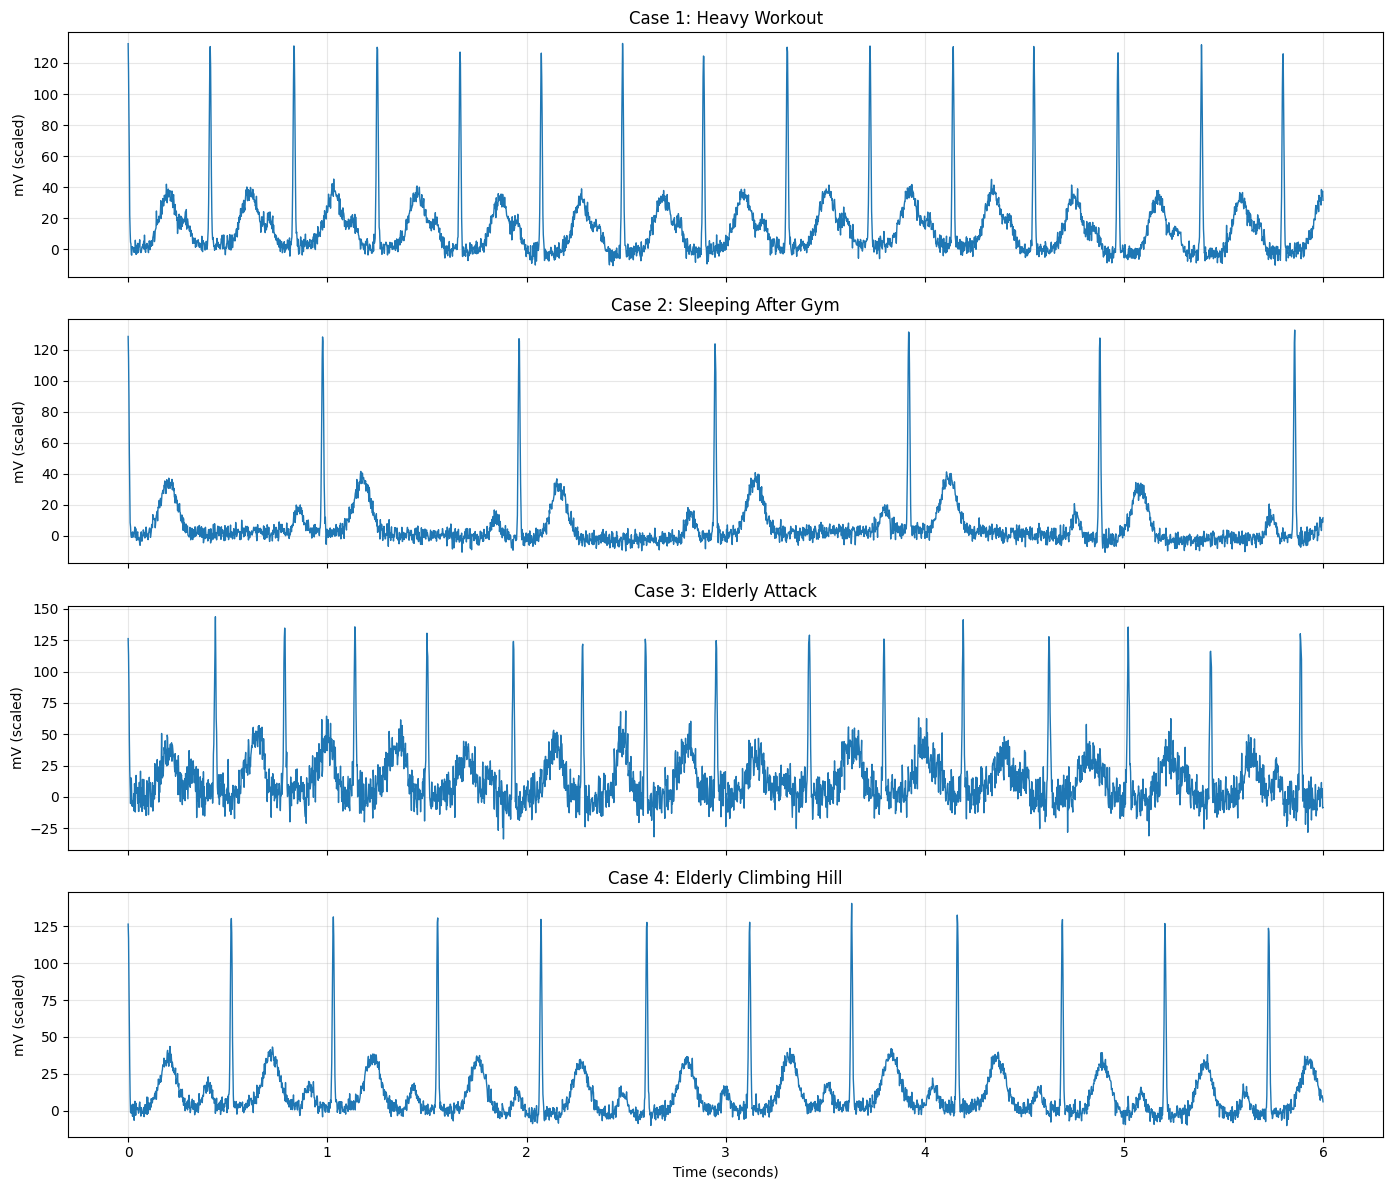

'docs/demo1/demo1_case_waveforms.png'

In [22]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
samples_to_show = FS * 6

for i, case_id in enumerate([1, 2, 3, 4]):
    y = all_signals[case_id][:samples_to_show]
    x = np.arange(len(y)) / FS
    axes[i].plot(x, y, linewidth=1.0)
    axes[i].set_title(f"Case {case_id}: {CASE_MAP[case_id]['name']}")
    axes[i].set_ylabel('mV (scaled)')
    axes[i].grid(alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout()
plot_path = os.path.join(OUT_DIR, 'demo1_case_waveforms.png')
plt.savefig(plot_path, dpi=180)
plt.show()
plot_path

In [27]:
csv_path = os.path.join(OUT_DIR, 'demo1_summary.csv')
json_path = os.path.join(OUT_DIR, 'demo1_report.json')

summary_df.to_csv(csv_path, index=False)

report = {
    'demo_name': 'Demo 1',
    'objective': '5-minute simulated 4-case cardiac triage run',
    'tested_with_model': True,
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'run_window_utc': {
        'start': start_ts.isoformat(),
        'end': end_ts.isoformat()
    },
    'sampling_rate_hz': FS,
    'phase_seconds': PHASE_SECONDS,
    'total_seconds': TOTAL_SECONDS,
    'model_status': MODEL_STATUS,
    'cases': summary_df.to_dict(orient='records'),
    'artifacts': {
        'summary_csv': csv_path.replace('\\', '/'),
        'report_json': json_path.replace('\\', '/'),
        'waveform_plot': plot_path.replace('\\', '/')
    }
}

with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2)

print('Saved:', csv_path)
print('Saved:', json_path)
print('Saved:', plot_path)

Saved: docs/demo1/demo1_summary.csv
Saved: docs/demo1/demo1_report.json
Saved: docs/demo1/demo1_case_waveforms.png


In [17]:
from pathlib import Path

check_paths = [
    Path('/content/docs/demo1'),
    Path('/content/drive/MyDrive/PULSEAI/docs/demo1'),
    Path('docs/demo1').resolve(),
    Path(r'g:/My Drive/PULSEAI/docs/demo1'),
]

for p in check_paths:
    print(p, 'exists=', p.exists())
    if p.exists():
        print('files=', sorted([x.name for x in p.iterdir()])[:20])

/content/docs/demo1 exists= True
files= ['demo1_case_waveforms.png', 'demo1_report.json', 'demo1_summary.csv']
/content/drive/MyDrive/PULSEAI/docs/demo1 exists= False
/content/docs/demo1 exists= True
files= ['demo1_case_waveforms.png', 'demo1_report.json', 'demo1_summary.csv']
g:/My Drive/PULSEAI/docs/demo1 exists= False


In [18]:
import shutil
from pathlib import Path

src_dir = Path('/content/docs/demo1')
target_candidates = [
    Path('/content/drive/MyDrive/PULSEAI/docs/demo1'),
    Path('/content/drive/MyDrive/PULSEAI-main/docs/demo1'),
]

copied = False
for target_dir in target_candidates:
    if target_dir.parent.exists():
        target_dir.mkdir(parents=True, exist_ok=True)
        for name in ['demo1_summary.csv', 'demo1_report.json', 'demo1_case_waveforms.png']:
            shutil.copy2(src_dir / name, target_dir / name)
        print('Copied artifacts to:', target_dir)
        copied = True
        break

if not copied:
    print('Drive repo path not mounted yet. Artifacts are available at:', src_dir)
    print('Mount Google Drive and rerun this cell to sync into repo docs/demo1/.')

Drive repo path not mounted yet. Artifacts are available at: /content/docs/demo1
Mount Google Drive and rerun this cell to sync into repo docs/demo1/.


In [28]:
# Emit canonical artifact payloads so they can be mirrored into local workspace if cloud sync lags.
import json

canonical_report = {
    'demo_name': 'Demo 1',
    'objective': '5-minute simulated 4-case cardiac triage run',
    'tested_with_model': True,
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'run_window_utc': {
        'start': start_ts.isoformat(),
        'end': end_ts.isoformat(),
    },
    'sampling_rate_hz': FS,
    'phase_seconds': PHASE_SECONDS,
    'total_seconds': TOTAL_SECONDS,
    'model_status': MODEL_STATUS,
    'cases': summary_df.to_dict(orient='records'),
    'artifacts': {
        'summary_csv': 'docs/demo1/demo1_summary.csv',
        'report_json': 'docs/demo1/demo1_report.json',
        'waveform_plot': 'docs/demo1/demo1_case_waveforms.png'
    }
}

print('CSV_START')
print(summary_df.to_csv(index=False))
print('CSV_END')
print('JSON_START')
print(json.dumps(canonical_report, indent=2))
print('JSON_END')

CSV_START
case_id,case_name,duration_seconds,expected_pattern,simulated_bpm,simulated_rr_cv,model_classification,risk_level,confidence,model_hr_bpm,model_rr_cv,signal_quality,model_used
1,Heavy Workout,75,Tachycardia Pattern,145.17,0.0117,Atrial Fibrillation (AFib),critical,0.883,,,good,keras:hctg_net_model.h5
2,Sleeping After Gym,75,Normal Sinus Rhythm,62.05,0.011,Atrial Fibrillation (AFib),critical,1.0,,,good,keras:hctg_net_model.h5
3,Elderly Attack,75,Atrial Fibrillation (AFib),156.03,0.1299,Atrial Fibrillation (AFib),critical,1.0,,,good,keras:hctg_net_model.h5
4,Elderly Climbing Hill,75,Normal Sinus Rhythm,114.95,0.012,Atrial Fibrillation (AFib),critical,1.0,,,good,keras:hctg_net_model.h5

CSV_END
JSON_START
{
  "demo_name": "Demo 1",
  "objective": "5-minute simulated 4-case cardiac triage run",
  "tested_with_model": true,
  "generated_at_utc": "2026-03-17T08:22:02.795790+00:00",
  "run_window_utc": {
    "start": "2026-03-17T08:21:11.224025+00:00",
    "end": "2026-03-17T08:21:1

## Execution Checklist

- Run all cells in sequence.
- Confirm files are generated in docs/demo1/.
- Use demo1_summary.csv and demo1_report.json as evidence in the presentation.